In [1]:
import torch

x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]

In [2]:
X = torch.tensor(x).float()
Y = torch.tensor(y).float()

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X = X.to(device)
Y = Y.to(device)

In [4]:
import torch.nn as nn

In [5]:
print(nn.Linear(2, 7))

Linear(in_features=2, out_features=7, bias=True)


In [6]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2, 8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8, 1)

    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x

In [7]:
mynet = MyNeuralNet().to(device)

In [8]:
mynet.input_to_hidden_layer.weight

Parameter containing:
tensor([[-0.2209,  0.6075],
        [ 0.5643,  0.3667],
        [-0.1894, -0.6799],
        [-0.6916,  0.1387],
        [-0.3111, -0.4928],
        [ 0.1098,  0.4440],
        [ 0.6977, -0.2976],
        [-0.2289,  0.3070]], requires_grad=True)

In [9]:
mynet.parameters()

<generator object Module.parameters at 0x7f2cdf554ba0>

In [10]:
for par in mynet.parameters():
    print(par)

Parameter containing:
tensor([[-0.2209,  0.6075],
        [ 0.5643,  0.3667],
        [-0.1894, -0.6799],
        [-0.6916,  0.1387],
        [-0.3111, -0.4928],
        [ 0.1098,  0.4440],
        [ 0.6977, -0.2976],
        [-0.2289,  0.3070]], requires_grad=True)
Parameter containing:
tensor([ 0.3133, -0.2153, -0.0553, -0.1909,  0.0623, -0.2260, -0.3499,  0.6971],
       requires_grad=True)
Parameter containing:
tensor([[-0.2804, -0.1543,  0.3156,  0.2493,  0.0773,  0.3291, -0.0878,  0.2253]],
       requires_grad=True)
Parameter containing:
tensor([0.1928], requires_grad=True)


In [11]:
loss_func = nn.MSELoss()

In [12]:
_Y = mynet(X)
loss_value = loss_func(_Y, Y)
print(loss_value)

tensor(104.3155, grad_fn=<MseLossBackward0>)


In [13]:
from torch.optim import SGD

opt = SGD(mynet.parameters(), lr=0.001)

In [14]:
opt.zero_grad() # flush the previous epoch's gradients
loss_value = loss_func(mynet(X), Y)
loss_value.backward() # perform backpropagation
opt.step() # update the weights according to the #gradients computed

In [15]:
loss_history = []
for _ in range(50):
    opt.zero_grad()
    loss_value = loss_func(mynet(X), Y)
    loss_value.backward()
    opt.step()
    loss_history.append(loss_value.item())

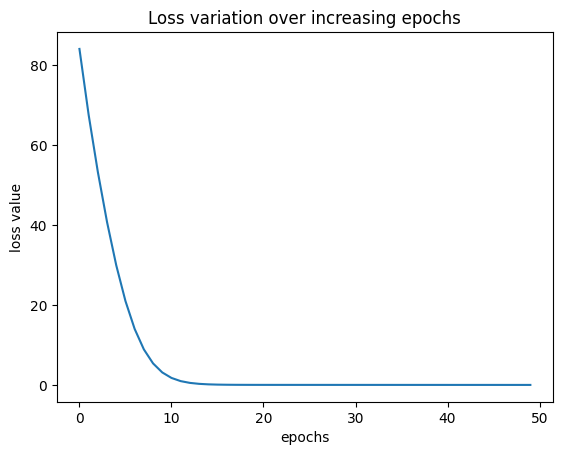

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(loss_history)
plt.title('Loss variation over increasing epochs')
plt.xlabel('epochs')
plt.ylabel('loss value')
plt.show()